# Import

In [14]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4
from qick.asm_v2 import AveragerProgramV2

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.179"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_adf5eb91e4d54a66b2364b168a31a778@192.168.10.179:42867
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Thu Jul 17 21:51:23 2025):

	Global clocks (MHz): tProc dispatcher timing 614.400, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 2], [DAC tile 3], [ADC tile 2]

	6 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 16384 complex samples (1.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_sg_mux8_v1 - fs=9830.400 Msps, fabric=614.400 MHz
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_sg_int4_v2 - fs=6881.280 Msps, fabric=430.080 MHz
		envelope memory: 4096 complex samples (9.524 us)


In [15]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

config_all = ExperimentConfig(config_list)
config_all.update("res.res_gain_ge", 1)
config_all.update("res.nqz_res", 1)

arm_qubit = ["Q1", "Q2", "Q3", "Q4"]
run_cfg = config_all.muxconfig(arm_qubit, mux_gen=1)


In [31]:
"""
BaseProgram: Base class for all QICK programs.
================================================
Centralizes generator declaration, readout, qubit pulse setup (prefix-aware),
standard gates, cooling, and measurement.
Subclasses only need to implement _initialize() and _body().
"""

from qick.asm_v2 import AveragerProgramV2


# ── Gate Name Mapping ──
# Maps shorthand gate names to pulse name templates.
# {pfx} is replaced by the transition prefix (e.g. "ge", "ef").
GATE_ALIAS = {
    # Clifford shorthand (used in AllXY / Tomography)
    "X": "x180_{pfx}",
    "Y": "y180_{pfx}",
    "X/2": "x90_{pfx}",
    "-X/2": "x90m_{pfx}",
    "Y/2": "y90_{pfx}",
    "-Y/2": "y90m_{pfx}",
    # Bare names without prefix
    "x180": "x180_{pfx}",
    "y180": "y180_{pfx}",
    "x90": "x90_{pfx}",
    "x90m": "x90m_{pfx}",
    "y90": "y90_{pfx}",
    "y90m": "y90m_{pfx}",
}


def resolve_gate(name, prefix="ge"):
    """Resolve shorthand gate name to actual pulse name.

    Examples:
        resolve_gate("X")      -> "x180_ge"
        resolve_gate("-X/2")   -> "x90m_ge"
        resolve_gate("x90")    -> "x90_ge"
        resolve_gate("x180_ge") -> "x180_ge"  (pass-through)
        resolve_gate("I")      -> "I"          (identity)
    """
    if name in ("I", "-I", None, "None"):
        return name
    if name in GATE_ALIAS:
        return GATE_ALIAS[name].format(pfx=prefix)
    return name  # already fully qualified


class BaseProgram(AveragerProgramV2):
    """
    Base class for all QICK programs.

    Key helpers:
    - declare_gen_auto()      : auto-handle mixer_freq for axis_sg_int4_v2
    - setup_resonator()       : readout channel + pulse config
    - setup_qubit_gen()       : qubit gen declaration (prefix-aware: ge/ef)
    - setup_qb_pulse()        : flexible pulse (const/arb/flat_top, gauss/cosine)
    - setup_standard_gates()  : 6 calibration gates for AllXY/RB/Tomography
    - apply_cool()            : cooling channel + pulse config
    - cooling_body()          : cooling pulse sequence for _body()
    - measure()               : readout pulse + trigger
    """

    # ── Generator helpers ──

    def declare_gen_auto(self, ch, nqz, mixer_key=None, cfg=None):
        """Declare generator, auto-handling mixer_freq for axis_sg_int4_v2."""
        if mixer_key and cfg and self.soccfg["gens"][ch]["type"] == "axis_sg_int4_v2":
            self.declare_gen(ch=ch, nqz=nqz, mixer_freq=cfg[mixer_key])
        else:
            self.declare_gen(ch=ch, nqz=nqz)

    def setup_qubit_gen(self, cfg, prefix="ge"):
        """
        Declare the qubit generator for a given prefix.
        ge -> cfg["qb_ch"] / nqz_qb / qb_mixer
        ef -> cfg["qb_ch_ef"] / nqz_qb_ef / qb_mixer_ef
        """
        if prefix == "ge":
            ch, nqz_key, mixer_key = cfg["qb_ch"], "nqz_qb", "qb_mixer"
        else:
            ch = cfg[f"qb_ch_{prefix}"]
            nqz_key = f"nqz_qb_{prefix}"
            mixer_key = f"qb_mixer_{prefix}"
        self.declare_gen_auto(ch, cfg[nqz_key], mixer_key, cfg)

    # ── Resonator setup ──

    def setup_resonator(self, cfg, prefix="ge"):
        """Configure resonator readout channel and flat_top pulse."""
        ro_ch = cfg["ro_ch"]
        res_ch = cfg["res_ch"]
        self.declare_gen(ch=res_ch, nqz=cfg["nqz_res"])
        self.declare_readout(ch=ro_ch, length=cfg["ro_length"])
        self.add_readoutconfig(
            ch=ro_ch, name="myro", freq=cfg[f"res_freq_{prefix}"], gen_ch=res_ch
        )
        self.add_gauss(
            ch=res_ch,
            name="readout",
            sigma=cfg["res_sigma"],
            length=5 * cfg["res_sigma"],
            even_length=True,
        )
        self.add_pulse(
            ch=res_ch,
            name="res_pulse",
            ro_ch=ro_ch,
            style="flat_top",
            envelope="readout",
            length=cfg["res_length"],
            freq=cfg[f"res_freq_{prefix}"],
            phase=cfg["res_phase"],
            gain=cfg[f"res_gain_{prefix}"],
        )

    # ── Mux pulse setup (flexible, prefix-aware) ──

    def set_mux(self, cfg, prefix="ge"):
        ro_chs = cfg["mux_ro_chs"]
        res_ch = cfg["mux_gen"]
        if  self.soccfg["gens"][res_ch]["type"] == "axis_sg_mux8_v1":
            self.declare_gen(
                ch=res_ch,
                nqz=2,
                ro_ch=ro_chs[0],
                mux_freqs=cfg[f"res_freq_{prefix}"],
                mux_gains=cfg[f"res_gain_{prefix}"],
                mux_phases=cfg["res_phase"],
            )
        elif self.soccfg["gens"][res_ch]["type"] == "axis_sg_mixmux8_v1":
            self.declare_gen(
                ch=res_ch,
                nqz=2,
                ro_ch=ro_chs[0],
                mixer_freq=cfg["mixer_freq"],
                mux_freqs=cfg[f"res_freq_{prefix}"],
                mux_gains=cfg[f"res_gain_{prefix}"],
                mux_phases=cfg["res_phase"],
            )
        for ch, f, ph in zip(
            cfg["mux_ro_chs"], cfg[f"res_freq_{prefix}"], cfg["mux_ro_phases"]
        ):
            self.declare_readout(
                ch=ch, length=cfg["ro_length"], freq=f, phase=ph, gen_ch=res_ch
            )

        self.add_pulse(
            ch=res_ch,
            name="readout",
            style="const",
            length=cfg["res_length"],
            mask=cfg["gen_mask"],
        )
    def set_qb_mux(self, cfg, prefix="ge"):

        qb_ch = cfg["mux_qb_ch"]
        if  self.soccfg["gens"][qb_ch]["type"] == "axis_sg_mux8_v1":
            self.declare_gen(
                ch=qb_ch,
                nqz=2,
                mux_freqs=cfg[f"qb_freq_{prefix}"],
                mux_gains=cfg[f"qb_gain_{prefix}"],
                mux_phases=cfg["qb_phase"],
            )
        elif self.soccfg["gens"][qb_ch]["type"] == "axis_sg_mixmux8_v1":
            self.declare_gen(
                ch=qb_ch,
                nqz=2,
                mixer_freq=cfg["mixer_freq"],
                mux_freqs=cfg[f"qb_freq_{prefix}"],
                mux_gains=cfg[f"qb_gain_{prefix}"],
                mux_phases=cfg["qb_phase"],
            )

        self.add_pulse(
            ch=qb_ch,
            name="qb_mux",
            style="const",
            length=cfg[f"qb_flat_top_length_{prefix}"],
            mask=cfg["gen_mask"],
        )
    # ── Qubit pulse setup (flexible, prefix-aware) ──

    def setup_qb_pulse(
        self,
        cfg,
        prefix="ge",
        pulse_type=None,
        shape="gauss",
        name="qb_pulse",
        phase=None,
        gain_key=None,
        gain_override=None,
        ch=None,
        length_mult=5,
    ):
        """
        Configure a qubit pulse with automatic channel/gain/phase resolution.
        Envelopes are deduplicated: multiple pulses with same prefix+shape
        share one envelope.

        Args:
            cfg:          configuration dict
            prefix:       'ge' or 'ef' — selects channel, freq, sigma keys
            pulse_type:   'const', 'arb', or 'flat_top' (default: cfg["pulse_type"])
            shape:        envelope shape — 'gauss' or 'cosine'
            name:         pulse name
            phase:        phase in degrees (default: cfg["qb_phase"] / cfg["qb_phase_ef"])
            gain_key:     explicit cfg key for gain (default: f"qb_gain_{prefix}")
            gain_override: explicit gain value (overrides gain_key when not None)
            ch:           explicit channel override
            length_mult:  envelope length = sigma * length_mult (default 5)
        """
        # Resolve channel
        if ch is None:
            ch = cfg["qb_ch"] if prefix == "ge" else cfg[f"qb_ch_{prefix}"]

        # Resolve pulse type from config if not specified
        if pulse_type is None:
            pulse_type = cfg.get("pulse_type", "arb")

        # Resolve phase from config if not specified
        if phase is None:
            if prefix == "ge":
                phase = cfg.get("qb_phase", 0)
            else:
                phase = cfg.get(f"qb_phase_{prefix}", 0)

        # Resolve gain: gain_override takes precedence over gain_key
        if gain_override is not None:
            gain = gain_override
        elif gain_key:
            gain = cfg[gain_key]
        else:
            gain = cfg.get(f"qb_gain_{prefix}", 0)

        # Resolve frequency
        freq = cfg[f"qb_freq_{prefix}"]

        # Add envelope if needed (deduplicated per channel+prefix+shape)
        env_name = None
        if pulse_type in ("arb", "flat_top"):
            env_name = f"env_{prefix}_{shape}"
            if not hasattr(self, "_added_envs"):
                self._added_envs = set()
            env_key = (ch, env_name)
            if env_key not in self._added_envs:
                sigma = cfg[f"sigma_{prefix}"]
                if shape in ("gauss", "gaussian"):
                    self.add_gauss(
                        ch=ch,
                        name=env_name,
                        sigma=sigma,
                        length=sigma * length_mult,
                        even_length=True,
                    )
                elif shape in ("cos", "cosine"):
                    self.add_cosine(
                        ch=ch,
                        name=env_name,
                        length=sigma * length_mult,
                        even_length=True,
                    )
                else:
                    raise ValueError(f"Unknown pulse shape: {shape}")
                self._added_envs.add(env_key)

        # Add pulse
        if pulse_type == "const":
            self.add_pulse(
                ch=ch,
                name=name,
                style="const",
                length=cfg[f"qb_length_{prefix}"],
                freq=freq,
                phase=phase,
                gain=gain,
            )
        elif pulse_type == "arb":
            self.add_pulse(
                ch=ch,
                name=name,
                style="arb",
                envelope=env_name,
                freq=freq,
                phase=phase,
                gain=gain,
            )
        elif pulse_type == "flat_top":
            self.add_pulse(
                ch=ch,
                name=name,
                style="flat_top",
                envelope=env_name,
                freq=freq,
                phase=phase,
                gain=gain,
                length=cfg[f"qb_flat_top_length_{prefix}"],
            )

    def setup_standard_gates(self, cfg, prefix="ge", pulse_type=None, shape="gauss"):
        """
        Setup 6 standard calibration gates for AllXY, RB, State Tomography:
        X180, Y180, X90, X90m, Y90, Y90m.
        """
        gates = [
            (f"x180_{prefix}", 0, f"pi_gain_{prefix}"),
            (f"y180_{prefix}", 90, f"pi_gain_{prefix}"),
            (f"x90_{prefix}", 0, f"pi2_gain_{prefix}"),
            (f"x90m_{prefix}", 180, f"pi2_gain_{prefix}"),
            (f"y90_{prefix}", 90, f"pi2_gain_{prefix}"),
            (f"y90m_{prefix}", -90, f"pi2_gain_{prefix}"),
        ]
        for gate_name, gate_phase, gain_key in gates:
            self.setup_qb_pulse(
                cfg,
                prefix=prefix,
                pulse_type=pulse_type,
                shape=shape,
                name=gate_name,
                phase=gate_phase,
                gain_key=gain_key,
            )

    # ── Cooling ──

    def apply_cool(self, cfg, style="flat_top"):
        """
        Configure cooling channels and pulses.
        style: "flat_top" (most experiments) or "const" (legacy).
        """
        for i in [1, 2]:
            ch_key = f"cool_ch{i}"
            if ch_key not in cfg:
                continue
            ch = cfg[ch_key]
            nqz = cfg.get(f"nqz_cool_ch{i}", 2)
            mixer_key = f"cool_mixer{i}"
            self.declare_gen_auto(ch, nqz, mixer_key, cfg)

            if style == "flat_top":
                env_name = f"cooling{i}"
                self.add_gauss(
                    ch=ch,
                    name=env_name,
                    sigma=cfg["res_sigma"],
                    length=cfg["res_sigma"] * 5,
                    even_length=True,
                )
                self.add_pulse(
                    ch=ch,
                    name=f"cool_pulse{i}",
                    envelope=env_name,
                    style="flat_top",
                    length=cfg["cool_length"],
                    freq=cfg[f"cool_freq_{i}"],
                    phase=0,
                    gain=cfg[f"cool_gain_{i}"],
                )
            else:  # const
                self.add_pulse(
                    ch=ch,
                    name=f"cool_pulse{i}",
                    style="const",
                    length=cfg["cool_length"],
                    freq=cfg[f"cool_freq_{i}"],
                    phase=0,
                    gain=cfg[f"cool_gain_{i}"],
                )

    def cooling_body(self, cfg, ring_down=0.5):
        """Execute cooling pulse sequence inside _body(). Returns True if cooling ran."""
        if not cfg.get("cooling", False):
            return False
        self.pulse(ch=cfg["cool_ch1"], name="cool_pulse1", t=0)
        self.pulse(ch=cfg["cool_ch2"], name="cool_pulse2", t=0)
        self.delay_auto(ring_down, tag="Ring down")
        return True

    # ── Measurement ──

    def measure(self, cfg):
        """Execute standard readout pulse + trigger."""
        self.pulse(ch=cfg["res_ch"], name="res_pulse", t=0)
        self.trigger(ros=[cfg["ro_ch"]], pins=[0], t=cfg["trig_time"])

    def measure_mux(self, cfg):
        """Execute MUX readout pulse + trigger."""
        self.pulse(ch=cfg["mux_gen"], name="readout", t=0)
        self.trigger(ros=cfg["mux_ro_chs"], pins=[0], t=0, ddr4=False)

# Config

In [17]:
class MixMuxGenMuxROProgram(BaseProgram):
    def _initialize(self, cfg):
        self.set_mux(cfg)

    def _body(self, cfg):
        self.measure_mux(cfg)


run_cfg.update({"res_length": 0.3, "ro_length": 1.5})
r = run_cfg['res_freq_ge']
run_cfg['res_freq_ge'] = np.array(r) + 0.2

prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=run_cfg)
iq_list = prog.acquire_decimated(soc, rounds=1000)
t = prog.get_time_axis(ro_index=0)


  0%|          | 0/1000 [00:00<?, ?it/s]

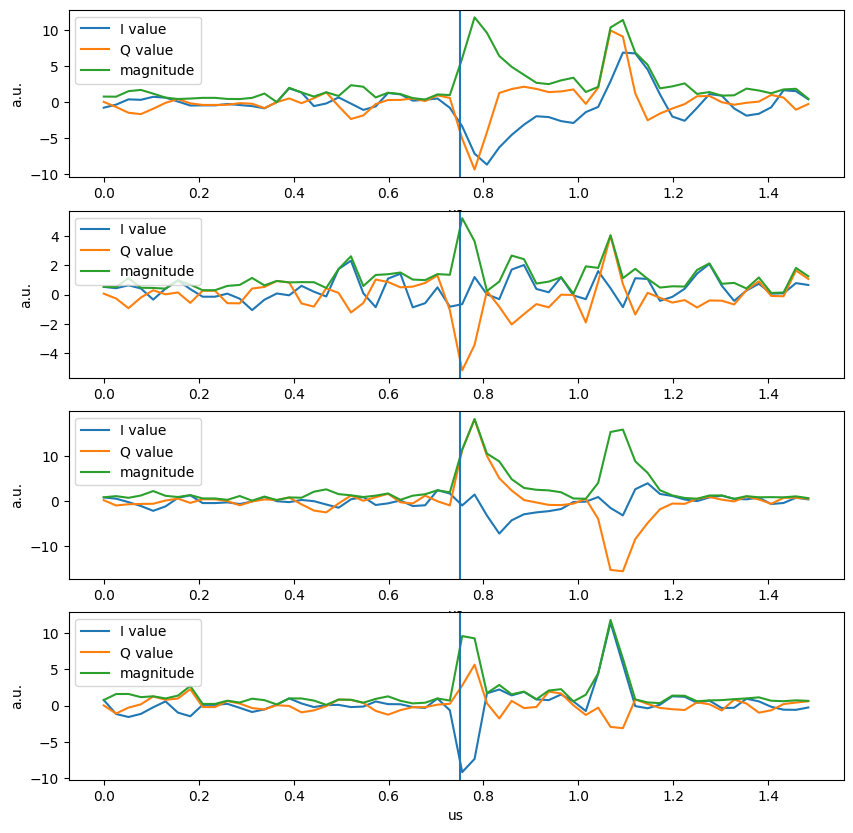

In [18]:
fig, axes = plt.subplots(len(run_cfg["mux_ro_chs"]), 1, figsize=(10, 10))
for i, ch in enumerate(run_cfg["mux_ro_chs"]):
    plot = axes[i]
    plot.plot(t, iq_list[i][:, 0], label="I value")
    plot.plot(t, iq_list[i][:, 1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1, 1j])), label="magnitude")
    plot.axvline(0.75)
    plot.legend(loc="upper left")
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")


# Onetone

In [19]:
from tqdm.auto import tqdm
import qick_workspace.tools.fitting as fitter


arm_qubit = ["Q1", "Q2", "Q3", "Q4"]

In [20]:
class MuxOneTone(BaseProgram):
    def _initialize(self, cfg):
        self.set_mux(cfg)

    def _body(self, cfg):
        self.measure_mux(cfg)

In [21]:
n_roch = len(arm_qubit)
F_Span = 10
F_Steps = 101
sweep = np.linspace(-F_Span, F_Span, F_Steps)
# z_list = [[] for _ in range(n_roch)]

run_cfg = config_all.muxconfig(arm_qubit, mux_gen=1)
r = run_cfg["res_freq_ge"]

# for i in tqdm(sweep):
#     run_cfg["res_freq_ge"] = np.array(r) + i

#     prog = MuxOneTone(soccfg, reps=100, final_delay=0.5, cfg=run_cfg)
#     results = prog.acquire(soc, rounds=1, progress=False)
#     for idx, res in enumerate(results):
#         z_list[idx].append(res[0][0] + 1j * res[0][1])

In [22]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math


def liveplot_1d_forloop(prog_class, arm_qubit, sweep, r, run_cfg, soc, soccfg, title):
    plt.close("all")
    plt.ion()

    n_roch = len(arm_qubit)
    z_list = [[] for _ in range(n_roch)]
    cols = 2 if n_roch <= 4 else 3
    rows = math.ceil(n_roch / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    ax_flat = np.atleast_1d(axes).flatten()

    lines = []
    for i in range(n_roch):
        (line,) = ax_flat[i].plot(
            [], [], ".-", label=f"{arm_qubit[i]} Data", markersize=4
        )
        ax_flat[i].set_title(f"{title}: {arm_qubit[i]}")
        ax_flat[i].set_xlabel("Frequency (MHz)")
        ax_flat[i].set_ylabel("Mag (a.u.)")
        ax_flat[i].legend(loc="upper right", fontsize="small")
        lines.append(line)

    for i in range(n_roch, len(ax_flat)):
        fig.delaxes(ax_flat[i])

    fig.canvas.manager.set_window_title("Quantum Resonator Live Sweep (QT)")
    fig.tight_layout()

    try:
        for sweep_idx, delta in tqdm(
            enumerate(sweep), total=len(sweep), desc="Frequency Sweep"
        ):
            run_cfg["res_freq_ge"] = np.array(r) + delta
            prog = prog_class(soccfg, reps=100, final_delay=0.5, cfg=run_cfg)
            results = prog.acquire(soc, rounds=1, progress=False)

            for res_idx, res in enumerate(results):
                z_list[res_idx].append(res[0][0] + 1j * res[0][1])

            for i in range(n_roch):
                freq_sweep_current = r[i] + sweep[: sweep_idx + 1]
                mag_response_current = np.abs(z_list[i])
                lines[i].set_data(freq_sweep_current, mag_response_current)
                ax_flat[i].relim()
                ax_flat[i].autoscale_view()

            fig.suptitle(f"Sweeping... Detune: {delta:.3f} MHz", y=0.98)
            fig.canvas.draw_idle()
            fig.canvas.flush_events()

    except KeyboardInterrupt:
        print("Sweep interrupted by user")

    # 回傳數據以及畫布物件 方便後續外部處理
    return z_list, fig, ax_flat


# --- 主程式執行 ---
# 1. 執行掃描並獲取數據與畫布
z_list, fig, ax_flat = liveplot_1d_forloop(
    MuxOneTone, arm_qubit, sweep, r, run_cfg, soc, soccfg, "resonator onetone"
)

# 2. 初始化擬合結果容器
n_roch = len(arm_qubit)
popt = [None] * n_roch
fit_res = [None] * n_roch

# 3. 外部擬合迴圈
for i in range(n_roch):
    freq_sweep = r[i] + sweep
    mag_response = np.abs(z_list[i])

    try:
        # 使用你指定的 fitter
        p_val, _ = fitter.fit_asym_lor(freq_sweep, mag_response)
        popt[i] = p_val
        fit_curve = fitter.asym_lorfunc(freq_sweep, *popt[i])

        # 直接在回傳的 ax_flat 上疊圖
        ax_flat[i].plot(
            freq_sweep,
            fit_curve,
            "r--",
            alpha=0.8,
            label=f"{arm_qubit[i]} Fit: {popt[i][2]:.2f}MHz",
        )
        ax_flat[i].axvline(popt[i][2], color="red", linestyle=":", alpha=0.5)
        ax_flat[i].legend(loc="upper right", fontsize="x-small")
        fit_res[i] = round(popt[i][2], 2)
    except Exception as e:
        print(f"Fit failed for {arm_qubit[i]}: {e}")

# 4. 最終更新與顯示
fig.suptitle("Sweep Completed - Final Fitting Results", fontweight="bold")
fig.tight_layout()
fig.canvas.draw()
plt.ioff()
plt.show()

Frequency Sweep: 100%|██████████| 101/101 [00:15<00:00,  6.53it/s]


In [17]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math


n_roch = len(arm_qubit)

F_Span = 10

F_Steps = 201

sweep_x = np.linspace(-F_Span, F_Span, F_Steps)

sweep_y = np.linspace(0, 1, 51)


def liveplot_2d_forloop(
    prog_class, arm_qubit, sweep_x, sweep_y, r, run_cfg, soc, soccfg, title
):
    """
    2D 掃描即時繪圖 (例如 Frequency vs Gain)
    sweep_x: 頻率偏移陣列 (內迴圈)
    sweep_y: Gain 陣列 (外迴圈)
    """
    plt.close("all")
    plt.ion()

    n_roch = len(arm_qubit)
    nx = len(sweep_x)
    ny = len(sweep_y)

    # 初始化 2D 複數矩陣 (y 軸為 Gain, x 軸為 Freq)
    z_mats = [np.full((ny, nx), np.nan, dtype=complex) for _ in range(n_roch)]

    cols = 2 if n_roch <= 4 else 3
    rows = math.ceil(n_roch / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), squeeze=False)
    ax_flat = axes.flatten()

    meshes = []
    cbars = []

    for i in range(n_roch):
        # 建立初始網格圖，X 軸顯示絕對頻率
        X, Y = np.meshgrid(sweep_x + r[i], sweep_y)
        # 初始數據填入零或 NaN
        mesh = ax_flat[i].pcolormesh(
            X, Y, np.zeros((ny, nx)), shading="auto", cmap="viridis"
        )
        ax_flat[i].set_title(f"Qubit: {arm_qubit[i]}")
        ax_flat[i].set_xlabel("Frequency (MHz)")
        ax_flat[i].set_ylabel("Gain (a.u.)")

        cbar = fig.colorbar(mesh, ax=ax_flat[i])
        cbar.set_label("Magnitude (a.u.)")

        meshes.append(mesh)
        cbars.append(cbar)

    for i in range(n_roch, len(ax_flat)):
        fig.delaxes(ax_flat[i])

    fig.canvas.manager.set_window_title(title)
    fig.tight_layout()

    # --- 2D 掃描核心 ---
    try:
        # 外迴圈：Gain (Y)
        for y_idx, gain in enumerate(tqdm(sweep_y, desc="Gain Sweep (Y)")):
            run_cfg["res_gain_ge"] = np.full(n_roch, gain)

            # 內迴圈：Frequency (X)
            for x_idx, freq in enumerate(sweep_x):
                run_cfg["res_freq_ge"] = np.array(r) + freq

                prog = prog_class(soccfg, reps=100, final_delay=0.5, cfg=run_cfg)
                results = prog.acquire(soc, rounds=100, progress=False)

                for res_idx, res in enumerate(results):
                    complex_val = res[0][0] + 1j * res[0][1]
                    z_mats[res_idx][y_idx, x_idx] = complex_val

                # 為了效能，內迴圈可以選擇每隔幾個點更新一次，或者只在內迴圈結束後更新
                # 這裡設定每掃完一個頻率點就更新一次（如果電腦太卡，可以移到內迴圈外）
                if x_idx % 5 == 0 or x_idx == nx - 1:
                    for i in range(n_roch):
                        mag_data = np.abs(z_mats[i])
                        meshes[i].set_array(mag_data.ravel())
                        # 自動調整顏色標尺
                        if not np.all(np.isnan(mag_data)):
                            meshes[i].set_clim(
                                vmin=np.nanmin(mag_data), vmax=np.nanmax(mag_data)
                            )

                    fig.canvas.draw_idle()
                    fig.canvas.flush_events()

            # 每掃完一條 Gain 線，更新標題資訊
            fig.suptitle(f"{title} | Current Gain: {gain:.3f}", y=0.98)

    except KeyboardInterrupt:
        print("Sweep interrupted by user")

    fig.suptitle(f"{title} - Completed", fontweight="bold")
    plt.ioff()
    plt.show()

    return z_mats, fig, ax_flat


# --- 呼叫方式 ---
z_mats, fig, axes = liveplot_2d_forloop(
    MuxOneTone,
    arm_qubit,
    sweep_x,
    sweep_y,
    r,
    run_cfg,
    soc,
    soccfg,
    "Resonator Punch-out",
)

The readout at 733.500 MHz may see some crosstalk from the tone at 710.500 MHz.
The readout at 733.600 MHz may see some crosstalk from the tone at 710.600 MHz.
The readout at 733.700 MHz may see some crosstalk from the tone at 710.700 MHz.
The readout at 733.800 MHz may see some crosstalk from the tone at 710.800 MHz.
The readout at 733.900 MHz may see some crosstalk from the tone at 710.900 MHz.
The readout at 734.000 MHz may see some crosstalk from the tone at 711.000 MHz.
The readout at 734.100 MHz may see some crosstalk from the tone at 711.100 MHz.
The readout at 734.200 MHz may see some crosstalk from the tone at 711.200 MHz.
The readout at 734.300 MHz may see some crosstalk from the tone at 711.300 MHz.
The readout at 734.400 MHz may see some crosstalk from the tone at 711.400 MHz.
The readout at 734.500 MHz may see some crosstalk from the tone at 711.500 MHz.
The readout at 734.600 MHz may see some crosstalk from the tone at 711.600 MHz.
The readout at 734.700 MHz may see some 

In [25]:
print(run_cfg['res_freq_ge'])
print(fit_res)

[6727. 6750. 6823. 6900.]
[np.float64(6716.85), np.float64(6738.89), np.float64(6812.85), np.float64(6889.2)]


In [63]:
res = [6720.8047,  6719.9914,6811.2465,6890]

In [66]:
config_all.update_mux(param='res.res_freq_ge', value=res, q_index=arm_qubit)
config_all.update_mux(param='res.res_gain_ge', value=0.3, q_index=arm_qubit)
run_cfg = config_all.muxconfig(arm_qubit, mux_gen=1)
print(run_cfg['res_freq_ge'])
print(run_cfg['res_gain_ge'])
print(run_cfg['qb_freq_ge'])

[6720.8047, 6719.9914, 6811.2465, 6890]
[0.3, 0.3, 0.3, 0.3]
[2872.649825, 3620.80596, 2777.488323, 3312.01532]


# TwoTone

In [67]:
class MuxTwoTone(BaseProgram):

    def _initialize(self, cfg):
        self.set_mux(cfg)
        self.set_qb_mux(cfg)

    def _body(self, cfg):
        self.pulse(ch=cfg["mux_qb_ch"], name="qb_mux", t=0)
        self.delay_auto(0.05)
        self.measure_mux(cfg)

In [68]:
# 1. 準備原始頻率（純數字）
base_freqs = np.array(config_all.muxconfig(arm_qubit, mux_gen=1)['qb_freq_ge'])
run_cfg = config_all.muxconfig(arm_qubit, mux_gen=1)
run_cfg['mux_qb_ch'] = 1
run_cfg['qb_flat_top_length_ge'] = 2
# 2. 設定掃描範圍
offsets = np.linspace(-20, 20, 51) # 對應原先的 sweep
z_array = np.zeros((len(base_freqs), len(offsets)), dtype=complex)
for i, offset in enumerate(tqdm(offsets)):
    # 這裡確保傳入的是「純數字」列表，而不是 QickParam
    run_cfg['qb_freq_ge'] = (base_freqs + offset).tolist() 
    # 每次編譯並運行一個點
    prog = MuxTwoTone(soccfg, reps=100, final_delay=0.5, cfg=run_cfg)
    results = prog.acquire(soc, rounds=100, progress=False)
    z_array[:, i] = np.squeeze(results).dot([1, 1j])

  0%|          | 0/51 [00:00<?, ?it/s]Two tones on same PFB channel:
You have readouts at frequencies 6719.991 and 6720.805 MHz.
(after rounding and accounting for the generator's digital mixer, if applicable).
Both map to the same PFB channel. In terms of the ADC's first Nyquist zone:
The tone frequencies are 652.809 and 651.995 MHz, and
the PFB channel range is [643.200, 662.400] MHz.
This is allowed, but you should expect crosstalk if you play one tone while reading out the other.
  2%|▏         | 1/51 [00:01<01:18,  1.57s/it]Two tones on same PFB channel:
You have readouts at frequencies 6719.991 and 6720.805 MHz.
(after rounding and accounting for the generator's digital mixer, if applicable).
Both map to the same PFB channel. In terms of the ADC's first Nyquist zone:
The tone frequencies are 652.809 and 651.995 MHz, and
the PFB channel range is [643.200, 662.400] MHz.
This is allowed, but you should expect crosstalk if you play one tone while reading out the other.
  4%|▍        

In [61]:
import matplotlib.pyplot as plt

# 轉換成 numpy array 方便計算
z_array = np.array(z_list) 

plt.figure(figsize=(10, 6))
for i in range(len(base_freqs)):
    # 計算振幅 (Amplitude)
    amps = np.abs(z_array[i])
    # 畫出頻率偏移 vs 振幅
    plt.plot(offsets, amps, label=f'Qubit {i+1}')

plt.xlabel('Frequency Offset (MHz)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Two-Tone Spectroscopy (MUX)')
plt.legend()
plt.show()